# From Histopathology Image to Graphs

In this tutorial we will take a histopathology image and convert it into graph-based representations.

We will generate:

1. Cell representation
2. Cell graph
3. Tissue representation
4. Tissue graph
5. Cell-to-tissue assignment matrix

The resulting representations will be used later to generate HACT embeddings for classical and quantum machine learning.

In [18]:
import os
import warnings
from pathlib import Path

import h5py
import numpy as np
import torch
import dgl

import matplotlib.pyplot as plt

from PIL import Image

from histocartography.preprocessing import (
    NucleiExtractor,
    DeepFeatureExtractor,
    KNNGraphBuilder,
    ColorMergedSuperpixelExtractor,
    RAGGraphBuilder,
)

from skimage.segmentation import mark_boundaries

warnings.filterwarnings("ignore")

## 1. Load a histopathology image

For this tutorial we will use a single BRACS image.

The image is the starting point for the entire graph representation.

In [5]:
IMAGE_PATH = "../data/images_demo/BRACS_1231_N_60.png"

image = Image.open(IMAGE_PATH)

print("Image size:", image.size)
print("Image mode:", image.mode)


Image size: (1434, 1727)
Image mode: RGB


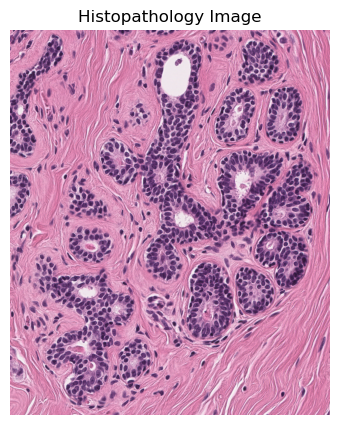

In [16]:
plt.figure(figsize=(5, 5))

plt.imshow(image)
plt.axis("off")
plt.title("Histopathology Image")

plt.show()

In [11]:
# Load image as a NumPy RGB array

image = np.array(
    Image.open(IMAGE_PATH).convert("RGB")
)

print("Image type:", type(image))
print("Image shape:", image.shape)

Image type: <class 'numpy.ndarray'>
Image shape: (1727, 1434, 3)


## 5. Detect nuclei

The first major processing step is nuclei detection.

We use the `NucleiExtractor` from Histocartography.

The extractor uses a PanNuke / HoVer-Net model to identify individual nuclei
in the histopathology image.

The output gives us two important pieces of information:

- An **instance map**, identifying individual nuclei
- The **centroid** of each detected nucleus

These detected nuclei form the basis of our cell-level representation.

In [12]:
print("Loading PanNuke / HoVer-Net...")

PANNUKE_MODEL = (
    "/home/lebo/Downloads/pannuke.pt"
)

nuclei_extractor = NucleiExtractor(
    model_path=PANNUKE_MODEL
)

print("Nuclei extractor loaded.")
print("Device:", nuclei_extractor.device)
print("Batch size:", nuclei_extractor.batch_size)

Loading PanNuke / HoVer-Net...
Nuclei extractor loaded.
Device: cpu
Batch size: 2


In [13]:
nuclei = nuclei_extractor.process(
    image
)

instance_map = nuclei[0]
centroids = nuclei[1]

instance_map = instance_map.astype(
    np.int32
)

print(
    "Number of detected nuclei:",
    len(centroids)
)

Patch-level nuclei detection: 100%|██████████| 50/50 [02:22<00:00,  2.85s/it]


Number of detected nuclei: 1374


## 6. Visualise the detected nuclei

We overlay the nuclei segmentation on top of the original image.

This allows us to visually check whether the nuclei detector is identifying
the cellular structures we expect.

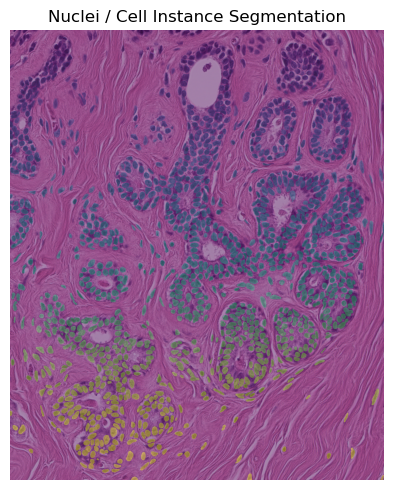

In [15]:
plt.figure(figsize=(5, 5))
plt.imshow(image)
plt.imshow(
    instance_map,
    alpha=0.45
)

plt.axis("off")
plt.title(
    "Nuclei / Cell Instance Segmentation"
)

plt.tight_layout()
plt.show()

## 7. Visualise individual nuclei boundaries

The previous visualisation showed the instance map as an overlay.

Here we explicitly draw the boundaries between detected nuclei.

Each segmented region represents an individual detected nucleus.

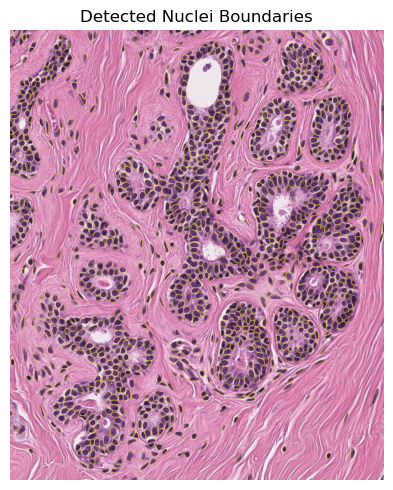

In [20]:
plt.figure(figsize=(5, 5))
plt.imshow(
    mark_boundaries(
        image,
        instance_map
    )
)

plt.axis("off")
plt.title(
    "Detected Nuclei Boundaries"
)

plt.tight_layout()
plt.show()

## 8. Visualise cell centroids

Each detected nucleus has a centroid.

A centroid provides a single `(x, y)` coordinate representing the approximate
centre of the cell.

These coordinates are important because the cell graph represents spatial
relationships between cells.

In other words:

**Nuclei → cells → spatial coordinates → cell graph**

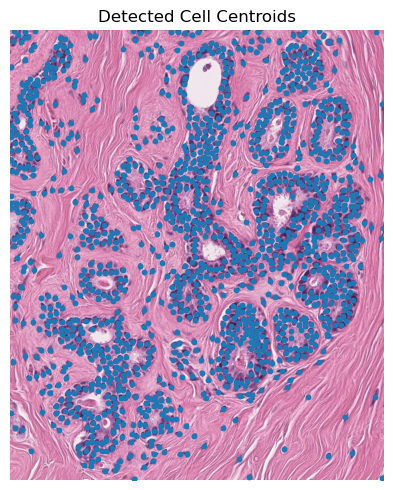

In [21]:
plt.figure(figsize=(5, 5))
plt.imshow(image)
plt.scatter(
    centroids[:, 0],
    centroids[:, 1],
    s=10
)

plt.axis("off")

plt.title(
    "Detected Cell Centroids"
)

plt.tight_layout()
plt.show()

## 9. Extract cell features

Detecting cells tells us **where the cells are**, but we also need to describe
their visual characteristics.

We use a ResNet-34 based deep feature extractor.

The extractor generates a feature vector for each detected cell.

The resulting matrix has the structure:

`number of cells × feature dimensions`

These features become node features in the cell graph.

In [24]:
print("Loading ResNet feature extractor...")

feature_extractor = DeepFeatureExtractor(
    architecture="resnet34",
    patch_size=72,
    resize_size=224,
    batch_size=32,
    num_workers=0,
)

print("Feature extractor loaded.")

Loading ResNet feature extractor...
Feature extractor loaded.


In [25]:
cell_features = feature_extractor.process(
    image,
    instance_map
)

print(
    "Cell feature matrix shape:",
    cell_features.shape
)

Cell feature matrix shape: torch.Size([1374, 512])


## 10. Construct the cell graph

We now turn the detected cells into a graph.

For this tutorial we use a **K-nearest-neighbour (KNN)** graph.

Each cell becomes a graph node.

Edges connect spatially neighbouring cells.

Therefore:

- Nodes = cells
- Node features = cell feature vectors
- Edges = spatial relationships between cells

This produces the cell-level component of the HACT representation.

In [28]:
knn_builder = KNNGraphBuilder(
    k=5
)

cell_graph = knn_builder.process(
    instance_map,
    cell_features
)

cell_graph.ndata["centroid"] = torch.tensor(
    centroids,
    dtype=torch.float32
)

cell_graph.ndata["feat"] = torch.tensor(
    cell_features,
    dtype=torch.float32
)

print(
    "Cell graph nodes:",
    cell_graph.num_nodes()
)

print(
    "Cell graph edges:",
    cell_graph.num_edges()
)

Cell graph nodes: 1374
Cell graph edges: 6870


## 11. Visualise the cell graph

We draw the graph edges on top of the original histopathology image.

This makes the graph representation easier to understand.

The biological image remains in the background, while the graph shows the
spatial relationships that will be used by downstream graph-based models.

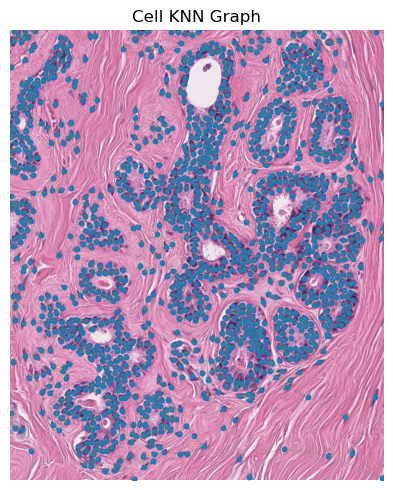

In [30]:
src, dst = cell_graph.edges()

src = src.numpy()
dst = dst.numpy()

plt.figure(figsize=(5, 5))

plt.imshow(image)

for s, d in zip(src, dst):

    x1, y1 = centroids[s]
    x2, y2 = centroids[d]

    plt.plot(
        [x1, x2],
        [y1, y2],
        linewidth=0.3,
        alpha=0.3
    )

plt.scatter(
    centroids[:, 0],
    centroids[:, 1],
    s=10
)

plt.axis("off")

plt.title(
    "Cell KNN Graph"
)

plt.tight_layout()

plt.show()

## 12. Generate tissue superpixels

We use Histocartography's `ColorMergedSuperpixelExtractor`.

The image is divided into approximately 100 visually coherent regions.

Each region receives a label in the superpixel map.

These regions will become the nodes of the tissue graph.

In [34]:
superpixel_extractor = (
    ColorMergedSuperpixelExtractor(
        nr_superpixels=100
    )
)

superpixel_result = superpixel_extractor.process(
    image
)

print("Returned type:", type(superpixel_result))

if isinstance(superpixel_result, tuple):
    superpixels = superpixel_result[0]
else:
    superpixels = superpixel_result

superpixels = np.asarray(
    superpixels
)

print(
    "Superpixel map shape:",
    superpixels.shape
)

print(
    "Superpixel map dtype:",
    superpixels.dtype
)

print(
    "Unique regions:",
    len(np.unique(superpixels))
)

Returned type: <class 'tuple'>
Superpixel map shape: (1727, 1434)
Superpixel map dtype: int64
Unique regions: 14


## 13. Visualise tissue regions

We overlay the boundaries of the generated tissue regions on the original
histopathology image.

This allows us to see how the image has been divided into larger regions.

These regions will become the nodes of the tissue graph.

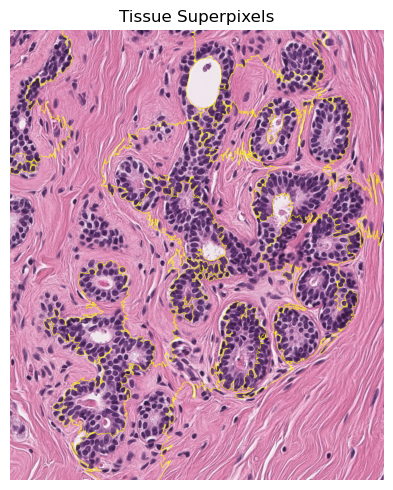

In [36]:
plt.figure(figsize=(5, 5))

plt.imshow(
    mark_boundaries(
        image,
        superpixels
    )
)

plt.axis("off")

plt.title(
    "Tissue Superpixels"
)

plt.tight_layout()

plt.show()

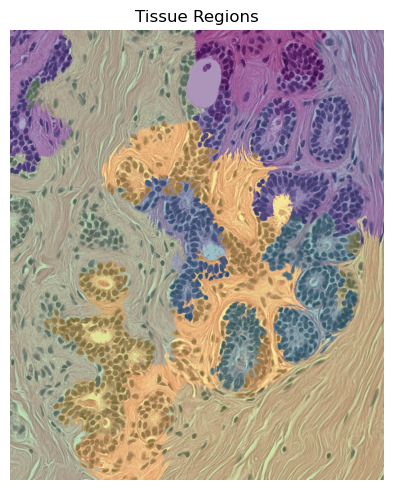

In [37]:
plt.figure(figsize=(5, 5))

plt.imshow(image)

plt.imshow(
    superpixels,
    alpha=0.40
)

plt.axis("off")

plt.title(
    "Tissue Regions"
)

plt.tight_layout()

plt.show()

## 14. Extract tissue features

Just as we extracted features for individual cells, we now extract features
for the tissue regions.

Each tissue region receives a feature vector describing its visual content.

The result is:

`tissue regions × feature dimensions`

In [38]:
tissue_features = feature_extractor.process(
    image,
    superpixels
)

if isinstance(tissue_features, tuple):
    tissue_features = tissue_features[0]

tissue_features = np.asarray(
    tissue_features
)

print(
    "Tissue feature matrix shape:",
    tissue_features.shape
)

Tissue feature matrix shape: (14, 512)


## 13. Construct the tissue graph

We now construct a graph between the tissue regions.

The `RAGGraphBuilder` creates a region adjacency graph.

The basic idea is:

- Nodes = tissue regions
- Node features = tissue feature vectors
- Edges = relationships between neighbouring tissue regions

This gives us the second graph in the hierarchical representation.

In [42]:
rag_builder = RAGGraphBuilder(
    kernel_size=3,
    hops=1
)

tissue_graph_result = rag_builder.process(
    superpixels,
    tissue_features
)

# Handle tuple output if returned
if isinstance(tissue_graph_result, tuple):
    tissue_graph = tissue_graph_result[0]
else:
    tissue_graph = tissue_graph_result

tissue_graph.ndata["feat"] = torch.tensor(
    tissue_features,
    dtype=torch.float32
)

print(
    "Tissue graph nodes:",
    tissue_graph.num_nodes()
)

print(
    "Tissue graph edges:",
    tissue_graph.num_edges()
)

Tissue graph nodes: 14
Tissue graph edges: 56


## 14. Calculate tissue centroids

To visualise the tissue graph, we need a coordinate representing the centre
of each tissue region.

We calculate the mean `(x, y)` position of all pixels belonging to each
region.

These coordinates are only used for visualisation.

In [43]:
tissue_centroids = []

for tissue_id in range(
    tissue_graph.num_nodes()
):

    ys, xs = np.where(
        superpixels == tissue_id
    )

    if len(xs) == 0:

        tissue_centroids.append(
            [0, 0]
        )

    else:

        tissue_centroids.append(
            [
                xs.mean(),
                ys.mean()
            ]
        )

tissue_centroids = np.asarray(
    tissue_centroids
)

print(
    "Tissue centroid shape:",
    tissue_centroids.shape
)

Tissue centroid shape: (14, 2)


## 15. Visualise the tissue graph

We now overlay the tissue graph on the original image.

The graph shows how neighbouring tissue regions are connected.

We can therefore compare the two graph levels:

**Cell graph:** individual cells and their spatial relationships.

**Tissue graph:** larger tissue regions and their spatial relationships.

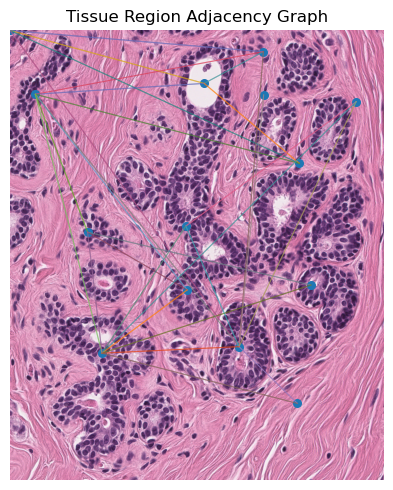

In [45]:
src, dst = tissue_graph.edges()

src = src.numpy()
dst = dst.numpy()

plt.figure(figsize=(5, 5))

plt.imshow(image)

for s, d in zip(src, dst):

    x1, y1 = tissue_centroids[s]
    x2, y2 = tissue_centroids[d]

    plt.plot(
        [x1, x2],
        [y1, y2],
        linewidth=0.8,
        alpha=0.5
    )

plt.scatter(
    tissue_centroids[:, 0],
    tissue_centroids[:, 1],
    s=30
)

plt.axis("off")

plt.title(
    "Tissue Region Adjacency Graph"
)

plt.tight_layout()

plt.show()

# 16. Connect the two graph levels

We now have:

- A cell graph
- A tissue graph

However, we still need to connect these two levels.

This is done using a **cell-to-tissue assignment matrix**.

The matrix tells us which tissue region each cell belongs to.

Conceptually:

    Cell graph
        ↓
    Assignment matrix
        ↓
    Tissue graph

This is what allows HACT to represent the hierarchy between cells and
larger tissue structures.

In [46]:
assignment = np.zeros(
    (
        cell_graph.num_nodes(),
        tissue_graph.num_nodes()
    ),
    dtype=np.float64
)

print(
    "Assignment matrix shape:",
    assignment.shape
)

Assignment matrix shape: (1374, 14)


## 17. Assign each cell to a tissue region

For each cell, we look at its centroid.

We then check which tissue superpixel contains that centroid.

This gives us the cell-to-tissue relationship.

Each cell should normally be assigned to one tissue region.

In [47]:
for i, (x, y) in enumerate(
    centroids
):

    x = int(round(x))
    y = int(round(y))

    if (
        0 <= y < superpixels.shape[0]
        and 0 <= x < superpixels.shape[1]
    ):

        tissue_id = int(
            superpixels[y, x]
        )

        if tissue_id > 0:

            tissue_id -= 1

            if (
                tissue_id
                < tissue_graph.num_nodes()
            ):

                assignment[
                    i,
                    tissue_id
                ] = 1.0

print(
    "Cells assigned:",
    np.sum(
        assignment.sum(axis=1) > 0
    )
)

print(
    "Total assignments:",
    int(
        assignment.sum()
    )
)

Cells assigned: 1374
Total assignments: 1374


## 18. Visualise the cell-to-tissue assignment matrix

We can visualise the assignment matrix as an image.

The rows represent cells.

The columns represent tissue regions.

A bright value indicates an assignment between a cell and a tissue region.

This matrix provides the connection between the two levels of the HACT
hierarchy.

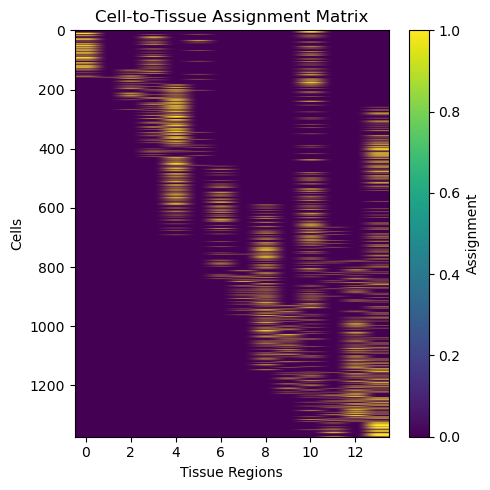

In [49]:
plt.figure(figsize=(5, 5))
plt.imshow(
    assignment,
    aspect="auto"
)

plt.xlabel(
    "Tissue Regions"
)

plt.ylabel(
    "Cells"
)

plt.title(
    "Cell-to-Tissue Assignment Matrix"
)

plt.colorbar(
    label="Assignment"
)

plt.tight_layout()
plt.show()

## 19. Visualise cell-to-tissue assignments on the image

We now return to the original image.

Each cell is coloured according to the tissue region to which it was
assigned.

This provides an intuitive visual representation of the relationship between
the cell-level and tissue-level representations.

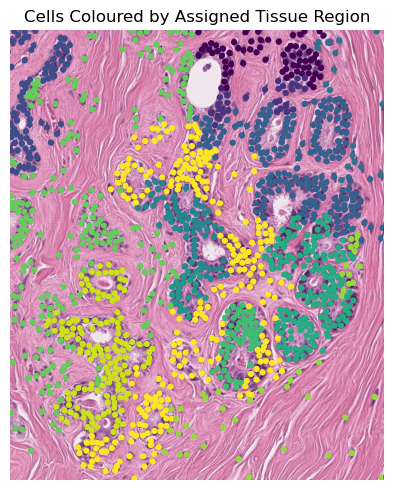

In [51]:
assigned_tissue = np.argmax(
    assignment,
    axis=1
)

plt.figure(figsize=(5, 5))
plt.imshow(image)

plt.scatter(
    centroids[:, 0],
    centroids[:, 1],
    c=assigned_tissue,
    s=12
)

plt.axis("off")
plt.title(
    "Cells Coloured by Assigned Tissue Region"
)

plt.tight_layout()
plt.show()

# 20. Visualise the complete hierarchical representation

We can now combine the important visual components into one image.

We show:

- The original tissue
- Tissue boundaries
- Cell locations

This provides an intuitive overview of the hierarchical representation
constructed from the histopathology image.

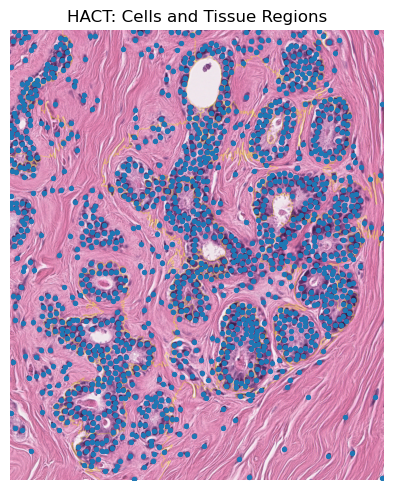

In [52]:
plt.figure(figsize=(5, 5))
plt.imshow(image)

plt.imshow(
    mark_boundaries(
        image,
        superpixels
    ),
    alpha=0.5
)

plt.scatter(
    centroids[:, 0],
    centroids[:, 1],
    s=8
)

plt.axis("off")

plt.title(
    "HACT: Cells and Tissue Regions"
)

plt.tight_layout()
plt.show()

# 21. Save the cell graph

The cell graph is stored as a DGL `.bin` file.

This file contains the graph structure and the node information required
for downstream graph-based processing.

We can later load this file without having to run nuclei detection and
feature extraction again.

In [56]:
from pathlib import Path

OUTPUT_DIR = Path("../data/cell_graphs")
cell_file = OUTPUT_DIR / "cell_graph.bin"

dgl.save_graphs(
    str(cell_file),
    [cell_graph]
)

print("Saved:", cell_file)

Saved: ../data/cell_graphs/cell_graph.bin


# 22. Save the tissue graph

The tissue graph is also stored as a DGL `.bin` file.

It contains the tissue-level graph structure and tissue node features.

In [57]:
tissue_file = (
    OUTPUT_DIR
    / "tissue_graph.bin"
)

dgl.save_graphs(
    str(tissue_file),
    [tissue_graph]
)

print(
    "Saved:",
    tissue_file
)

Saved: ../data/cell_graphs/tissue_graph.bin


# 23. Save the cell-to-tissue assignment matrix

The assignment matrix is saved as an HDF5 (`.h5`) file.

The matrix connects the cell graph to the tissue graph.

Therefore, our three main outputs are:

- `cell_graph.bin`
- `tissue_graph.bin`
- `assignment_matrix.h5`

These are the graph-level representations that can be used in the
subsequent HACT machine-learning workflow.

In [58]:
assignment_file = (
    OUTPUT_DIR
    / "assignment_matrix.h5"
)

with h5py.File(
    assignment_file,
    "w"
) as f:

    f.create_dataset(
        "assignment_matrix",
        data=assignment
    )

print(
    "Saved:",
    assignment_file
)

Saved: ../data/cell_graphs/assignment_matrix.h5
